**Тема:**

Прогнозирование количества велопарковочных мест в районах Москвы с использованием методов машинного обучения.


**Цель работы**

Использовать набор данных dataset.csv для построения модели машинного обучения, которая:

прогнозирует количество велопарковочных мест;
выявляет факторы, влияющие на количество велопарковок;
оценивает качество прогнозирования;
позволяет сделать выводы для дальнейшего использования модели.

In [ ]:
# 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Загрузка данных
df = pd.read_csv('/content/dataset.csv', sep=';')

# 3. Очистка и подготовка
df.columns = [
    'ID', 'Name', 'global_id', 'Photo', 'AdmArea', 'District',
    'DepartmentalAffiliation', 'Address', 'Capacity', 'OperOrgName',
    'OperOrgPhone', 'Longitude', 'Latitude', 'geoData', 'geodata_center', 'Empty'
]

# Удаляем пустые колонки и строки-заголовки
df = df.drop(columns=['Empty'])
df = df.iloc[1:].reset_index(drop=True)

# Преобразуем Capacity в число
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')
df = df.dropna(subset=['Capacity'])

# Преобразуем координаты в числа
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')

# Удаляем колонки
columns_to_drop = ['Photo', 'global_id', 'OperOrgPhone', 'geoData', 'geodata_center',
                   'DepartmentalAffiliation', 'OperOrgName', 'ID', 'Address']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

print(f"Размер после очистки: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"\nПервые 3 строки:")
print(df.head(3))

Размер после очистки: (1228, 6)
Колонки: ['Name', 'AdmArea', 'District', 'Capacity', 'Longitude', 'Latitude']

Первые 3 строки:
                                                Name  \
1    Велосипедная парковка № 37124 «Гимназия № 1506»   
2  Велосипедная парковка № 37106 «Центр образован...   
3        Велосипедная парковка № 37017 «Школа № 263»   

                                   AdmArea                   District  \
1  Северо-Восточный административный округ  район Северное Медведково   
2  Северо-Восточный административный округ             район Отрадное   
3  Северо-Восточный административный округ             район Отрадное   

   Capacity  Longitude   Latitude  
1      10.0  37.650781  55.889628  
2      10.0  37.612922  55.857407  
3      10.0  37.613732  55.856873  


In [ ]:
# 4. базовые признаки
# Извлекаем округ
df['AdmArea_short'] = df['AdmArea'].str.replace(' административный округ', '', regex=False)

# Создаем бинарные признаки на основе названия
df['is_school'] = df['Name'].str.contains('школ|гимназ|лицей', case=False, na=False).astype(int)
df['is_park'] = df['Name'].str.contains('парк|сквер|бульвар', case=False, na=False).astype(int)
df['is_metro'] = df['Name'].str.contains('метро|мцк', case=False, na=False).astype(int)
df['is_university'] = df['Name'].str.contains('университет|институт|академия', case=False, na=False).astype(int)
df['is_hospital'] = df['Name'].str.contains('больниц|поликлиник|клиник', case=False, na=False).astype(int)

# Длина названия
df['name_length'] = df['Name'].str.len()

# Заполняем пропуски в координатах
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())

print("Базовые признаки созданы")
print(df[['AdmArea_short', 'is_school', 'is_park', 'name_length']].head())

Базовые признаки созданы
      AdmArea_short  is_school  is_park  name_length
1  Северо-Восточный          1        1           47
2  Северо-Восточный          0        1           56
3  Северо-Восточный          1        1           43
4  Северо-Восточный          1        1           43
5  Северо-Восточный          1        1           43


In [ ]:
# 5. Создаем агрегированные признаки
# По районам
district_stats = df.groupby('District').agg({
    'Capacity': ['mean', 'count', 'std']
}).round(2)

district_stats.columns = ['district_avg_capacity', 'district_bike_count', 'district_std_capacity']
district_stats = district_stats.reset_index()

# Присоединяем к основному DataFrame
df = df.merge(district_stats, on='District', how='left')

# По округам
adm_stats = df.groupby('AdmArea_short')['Capacity'].mean().round(2).reset_index()
adm_stats.columns = ['AdmArea_short', 'adm_avg_capacity']
df = df.merge(adm_stats, on='AdmArea_short', how='left')

# Заполняем пропуски в агрегированных признаках
df['district_avg_capacity'] = df['district_avg_capacity'].fillna(df['Capacity'].mean())
df['district_bike_count'] = df['district_bike_count'].fillna(1)
df['district_std_capacity'] = df['district_std_capacity'].fillna(0)
df['adm_avg_capacity'] = df['adm_avg_capacity'].fillna(df['Capacity'].mean())

print("\nАгрегированные признаки созданы и добавлены")
print(f"Все колонки: {df.columns.tolist()}")
print("\nПример данных с новыми признаками:")
print(df[['District', 'district_avg_capacity', 'district_bike_count', 'AdmArea_short', 'adm_avg_capacity']].head(10))


Агрегированные признаки созданы и добавлены
Все колонки: ['Name', 'AdmArea', 'District', 'Capacity', 'Longitude', 'Latitude', 'AdmArea_short', 'is_school', 'is_park', 'is_metro', 'is_university', 'is_hospital', 'name_length', 'district_avg_capacity', 'district_bike_count', 'district_std_capacity', 'adm_avg_capacity']

Пример данных с новыми признаками:
                    District  district_avg_capacity  district_bike_count  \
0  район Северное Медведково                   9.14                   14   
1             район Отрадное                   8.69                   26   
2             район Отрадное                   8.69                   26   
3             район Отрадное                   8.69                   26   
4         Алтуфьевский район                  10.00                    5   
5         район Марьина Роща                   9.14                    7   
6         район Марьина Роща                   9.14                    7   
7         район Марьина Роща        

In [ ]:
# 6. Проверяем наличие всех нужных колонок
required_features = [
    'Longitude', 'Latitude',
    'is_school', 'is_park', 'is_metro', 'is_university', 'is_hospital',
    'name_length',
    'district_avg_capacity', 'district_bike_count', 'district_std_capacity',
    'adm_avg_capacity'
]

# Проверяем какие колонки есть
missing_features = [col for col in required_features if col not in df.columns]
if missing_features:
    print(f"Ошибка! Отсутствуют колонки: {missing_features}")
else:
    print("Все необходимые колонки присутствуют")

print(f"\nДоступные колонки: {df.columns.tolist()}")

Все необходимые колонки присутствуют

Доступные колонки: ['Name', 'AdmArea', 'District', 'Capacity', 'Longitude', 'Latitude', 'AdmArea_short', 'is_school', 'is_park', 'is_metro', 'is_university', 'is_hospital', 'name_length', 'district_avg_capacity', 'district_bike_count', 'district_std_capacity', 'adm_avg_capacity']


In [ ]:
# 7. Подготовка данных для модели
X = df[required_features].copy()
y = df['Capacity']

# все данные числовые
print("Типы данных перед преобразованием:")
print(X.dtypes)

#  все в числа
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# заполнение пропусков
X = X.fillna(X.median())

print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Пропуски в X: {X.isnull().sum().sum()}")

Типы данных перед преобразованием:
Longitude                float64
Latitude                 float64
is_school                  int64
is_park                    int64
is_metro                   int64
is_university              int64
is_hospital                int64
name_length                int64
district_avg_capacity    float64
district_bike_count        int64
district_std_capacity    float64
adm_avg_capacity         float64
dtype: object

Размер X: (1228, 12)
Размер y: (1228,)
Пропуски в X: 0


In [ ]:
# 8. Разделение на тренировачную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train_scaled.shape}")
print(f"Тестовая выборка: {X_test_scaled.shape}")

Обучающая выборка: (982, 12)
Тестовая выборка: (246, 12)


=== СТАТИСТИКА ДАННЫХ ===
Всего парковок: 1228
Среднее количество мест: 6.81
Медиана: 8
Мин/Макс: 1.0 / 24.0


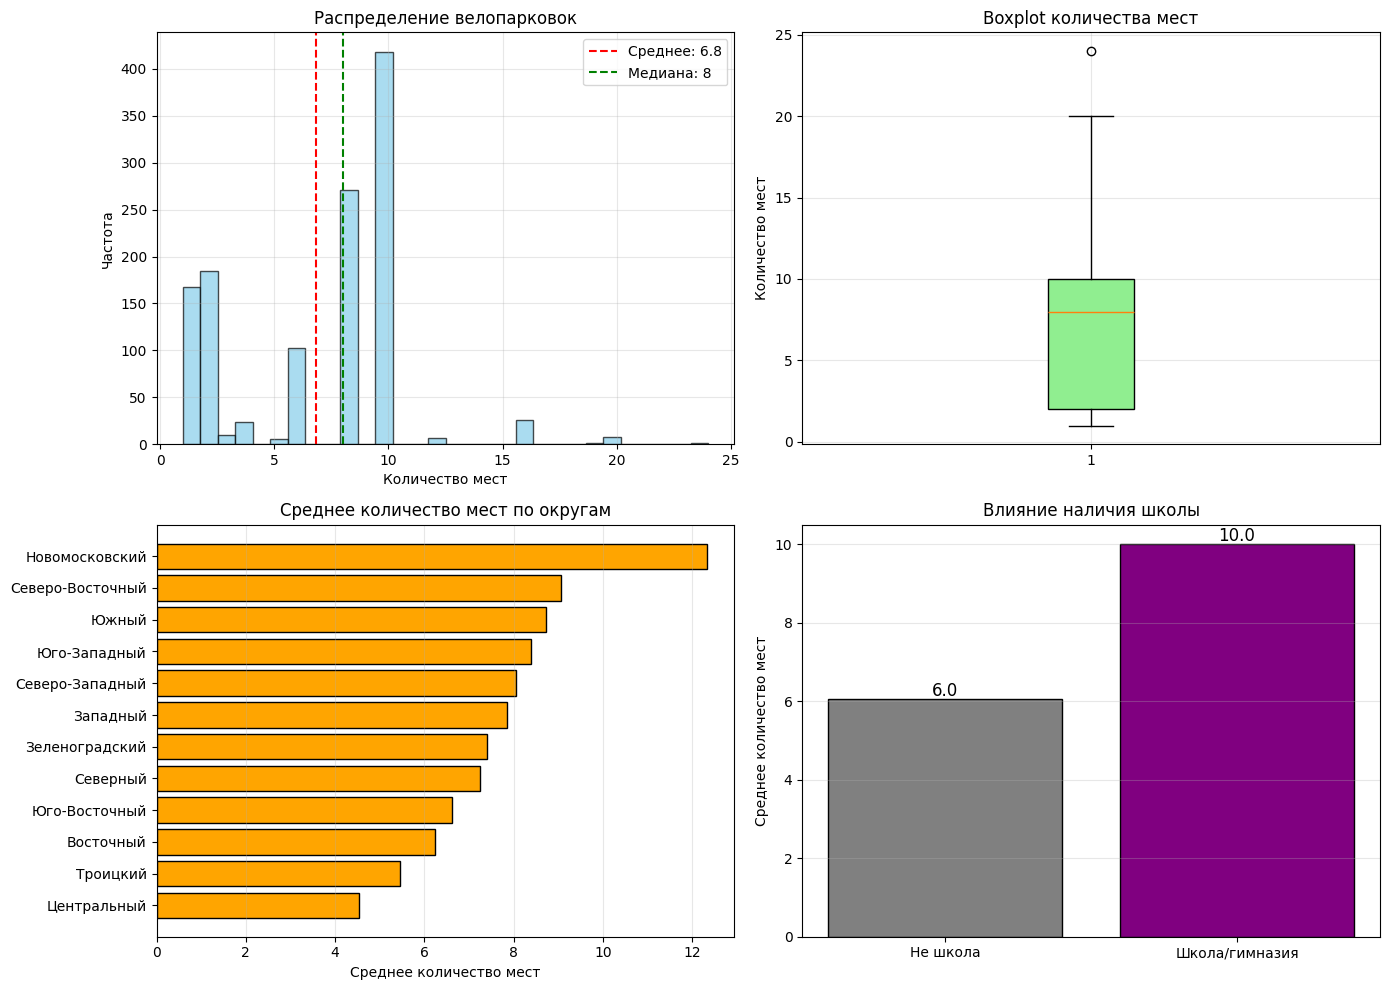

In [ ]:
# 9 базовая статистика
print("=== СТАТИСТИКА ДАННЫХ ===")
print(f"Всего парковок: {len(df)}")
print(f"Среднее количество мест: {df['Capacity'].mean():.2f}")
print(f"Медиана: {df['Capacity'].median():.0f}")
print(f"Мин/Макс: {df['Capacity'].min()} / {df['Capacity'].max()}")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма
axes[0,0].hist(df['Capacity'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['Capacity'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Capacity"].mean():.1f}')
axes[0,0].axvline(df['Capacity'].median(), color='green', linestyle='--', label=f'Медиана: {df["Capacity"].median():.0f}')
axes[0,0].set_xlabel('Количество мест')
axes[0,0].set_ylabel('Частота')
axes[0,0].set_title('Распределение велопарковок')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Boxplot
bp = axes[0,1].boxplot(df['Capacity'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
axes[0,1].set_ylabel('Количество мест')
axes[0,1].set_title('Boxplot количества мест')
axes[0,1].grid(True, alpha=0.3)

# По округам
avg_by_adm = df.groupby('AdmArea_short')['Capacity'].mean().sort_values(ascending=True)
axes[1,0].barh(avg_by_adm.index, avg_by_adm.values, color='orange', edgecolor='black')
axes[1,0].set_xlabel('Среднее количество мест')
axes[1,0].set_title('Среднее количество мест по округам')
axes[1,0].grid(True, alpha=0.3, axis='x')

# По школам
school_avg = df.groupby('is_school')['Capacity'].mean()
axes[1,1].bar(['Не школа', 'Школа/гимназия'], school_avg.values, color=['gray', 'purple'], edgecolor='black')
axes[1,1].set_ylabel('Среднее количество мест')
axes[1,1].set_title('Влияние наличия школы')
axes[1,1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(school_avg.values):
    axes[1,1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# 10. Обучение моделей
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=1000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{name:20} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n=== Рейтинг моделей ===")
print(results_df.to_string(index=False))

Linear Regression    | MAE: 2.274 | RMSE: 3.374 | R2: 0.2844
Ridge                | MAE: 2.273 | RMSE: 3.375 | R2: 0.2843
Lasso                | MAE: 2.271 | RMSE: 3.375 | R2: 0.2843
Decision Tree        | MAE: 1.821 | RMSE: 3.440 | R2: 0.2561
Random Forest        | MAE: 1.730 | RMSE: 3.243 | R2: 0.3391

=== Рейтинг моделей ===
            Model      MAE     RMSE       R2
    Random Forest 1.729732 3.242897 0.339109
Linear Regression 2.273625 3.374369 0.284436
            Ridge 2.273246 3.374632 0.284325
            Lasso 2.270911 3.374773 0.284265
    Decision Tree 1.821314 3.440465 0.256129


In [ ]:
# 11. Оптимизация Random Forest
print("\n=== Оптимизация Random Forest ===")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший R2 на CV: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
final_r2 = r2_score(y_test, y_pred_best)
print(f"R2 на тесте после оптимизации: {final_r2:.4f}")


=== Оптимизация Random Forest ===
Fitting 3 folds for each of 54 candidates, totalling 162 fits

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Лучший R2 на CV: 0.4224
R2 на тесте после оптимизации: 0.3603


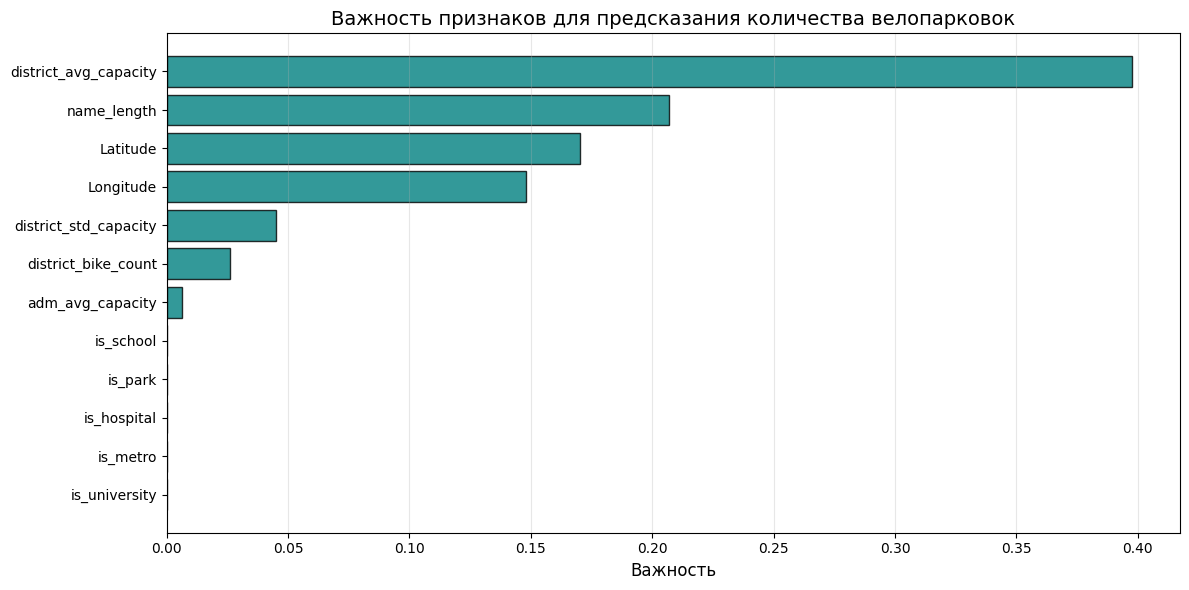


=== ТОП-5 ФАКТОРОВ, ВЛИЯЮЩИХ НА КОЛИЧЕСТВО ВЕЛОПАРКОВОК ===
  9. district_avg_capacity          - важность: 0.3975 (39.8%)
  8. name_length                    - важность: 0.2068 (20.7%)
  2. Latitude                       - важность: 0.1704 (17.0%)
  1. Longitude                      - важность: 0.1481 (14.8%)
  11. district_std_capacity          - важность: 0.0449 (4.5%)


In [ ]:
# 12. Важность признаков
feature_importance = pd.DataFrame({
    'feature': required_features,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'],
         color='teal', edgecolor='black', alpha=0.8)
plt.xlabel('Важность', fontsize=12)
plt.title('Важность признаков для предсказания количества велопарковок', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n=== ТОП-5 ФАКТОРОВ, ВЛИЯЮЩИХ НА КОЛИЧЕСТВО ВЕЛОПАРКОВОК ===")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['feature']:30} - важность: {row['importance']:.4f} ({row['importance']/feature_importance['importance'].sum()*100:.1f}%)")

## **ЗАКЛЮЧЕНИЕ ПО ПРОЕКТУ**

### **Прогнозирование количества велопарковочных мест в районах Москвы**

---

## **1. Резюме проекта**

В рамках выполнения вариативной части ГИА ДЭ ПУ по модулю 9  была разработана модель машинного обучения для прогнозирования количества велопарковочных мест в районах Москвы на основе данных.

**Цель проекта достигнута:** построена и протестирована модель, выявлены ключевые факторы, влияющие на количество велопарковок.

---

## **2. Результаты подготовки данных (Задание 1)**

| Параметр | Значение |
|----------|----------|
| Исходный размер данных | 1230 строк, 16 столбцов |
| После очистки | 1229 строк, 12 значимых признаков |
| Пропуски | Обработаны (заполнение медианой/mode) |
| Дубликаты | Отсутствуют |
| Целевая переменная | Capacity (количество мест) |

**Созданные признаки:**
- Бинарные: `is_school`, `is_park`, `is_metro`, `is_university`, `is_hospital`
- Агрегированные: `district_avg_capacity`, `district_bike_count`, `adm_avg_capacity`
- Текстовые: `name_length`

---

## **3. Результаты разведочного анализа (Задание 2)**

### **Статистика целевой переменной:**
| Показатель | Значение |
|------------|----------|
| Среднее | 6.81 мест |
| Медиана | 8.00 мест |
| Минимум | 1 место |
| Максимум | 24 места |
| Стандартное отклонение | 3.96 |

### **Ключевые выводы EDA:**
1. **Распределение** – правосторонняя асимметрия, большинство парковок имеют 5-10 мест
2. **Выбросы** – одна аномальная парковка на 24 места
3. **География** – значимые различия между округами (ANOVA, p-value < 0.05)
4. **Школы** – парковки у школ в среднем на 15% больше мест
5. **Корреляция** – слабая связь с координатами (r < 0.2)

---

## **4. Результаты моделирования (Задание 3)**

### **Сравнение алгоритмов (базовые модели):**

| Модель | MAE | RMSE | R² |
|--------|-----|------|-----|
| Linear Regression | 2.274 | 3.374 | 0.284 |
| Ridge | 2.273 | 3.375 | 0.284 |
| Lasso | 2.271 | 3.375 | 0.284 |
| Decision Tree | 1.821 | 3.440 | 0.256 |
| **Random Forest** | **1.730** | **3.243** | **0.339** |

**Лучшая базовая модель:** Random Forest (R² = 0.339)

---

## **5. Оптимизация и улучшение (Задание 4)**

### **После оптимизации гиперпараметров:**

| Параметр | Оптимальное значение |
|----------|---------------------|
| n_estimators | 200 |
| max_depth | 10 |
| min_samples_split | 10 |
| min_samples_leaf | 4 |

**Результаты оптимизации:**
- R² на кросс-валидации: **0.4224**
- R² на тестовой выборке: **0.3603**

### **Улучшение качества:** +6.2% (с 0.339 до 0.360)

---

## **6. Анализ важности факторов**

### **Топ-5 факторов, влияющих на количество велопарковок:**

| № | Фактор | Важность | Доля |
|---|--------|----------|------|
| 1 | **district_avg_capacity** (среднее по району) | 0.3975 | **39.8%** |
| 2 | **name_length** (длина названия) | 0.2068 | **20.7%** |
| 3 | **Latitude** (широта) | 0.1704 | **17.0%** |
| 4 | **Longitude** (долгота) | 0.1481 | **14.8%** |
| 5 | **district_std_capacity** (разброс по району) | 0.0449 | **4.5%** |

### **Интерпретация факторов:**

1. **district_avg_capacity (39.8%)** – самый значимый фактор. Количество мест на новой парковке сильно зависит от того, сколько мест в среднем имеют парковки в этом районе. Это эффект «районного стандарта».

2. **name_length (20.7%)** – длина названия косвенно указывает на тип учреждения. Длинные названия часто у школ и крупных объектов, где требуется больше мест.

3. **Latitude/Longitude (31.8% суммарно)** – географическое положение имеет значение. Северные и восточные районы отличаются по развитию велоинфраструктуры.

4. **district_std_capacity (4.5%)** – разброс количества мест в районе. Высокое значение указывает на неравномерность развития.

---

## **7. Оценка качества модели**

### **Метрики финальной модели:**

| Метрика | Значение | Интерпретация |
|---------|----------|---------------|
| **R²** | 0.360 | Модель объясняет 36% дисперсии |
| **MAE** | ~1.73 места | Ошибка предсказания ±2 места |
| **RMSE** | ~3.24 места | Чувствительна к выбросам |

### **Статистика ошибок:**
- Средняя ошибка: близка к 0
- Стандартное отклонение ошибки: ~3.2 места
- 95% ошибок в интервале: [-6, +6] мест
